ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [3]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [5]:
print("Shape:", df.shape)
print(f"The dataset has {df.shape[0]} rows (customers) and {df.shape[1]} columns (features).")

Shape: (8950, 18)
The dataset has 8950 rows (customers) and 18 columns (features).


**Check basic information about the dataset using `info()`.**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [7]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [8]:
df.drop(columns=['CUST_ID'], inplace=True)
print("CUST_ID column dropped.")
print("New shape:", df.shape)

CUST_ID column dropped.
New shape: (8950, 17)


**Check the missing values in each column.**

In [9]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [10]:
df.fillna(df.mean(), inplace=True)
print("Missing values filled with column means.")

Missing values filled with column means.


**Check the missing values again to make sure they were handled.**

In [11]:
print("Remaining missing values:")
print(df.isnull().sum().sum(), "missing values remain.")

Remaining missing values:
0 missing values remain.


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

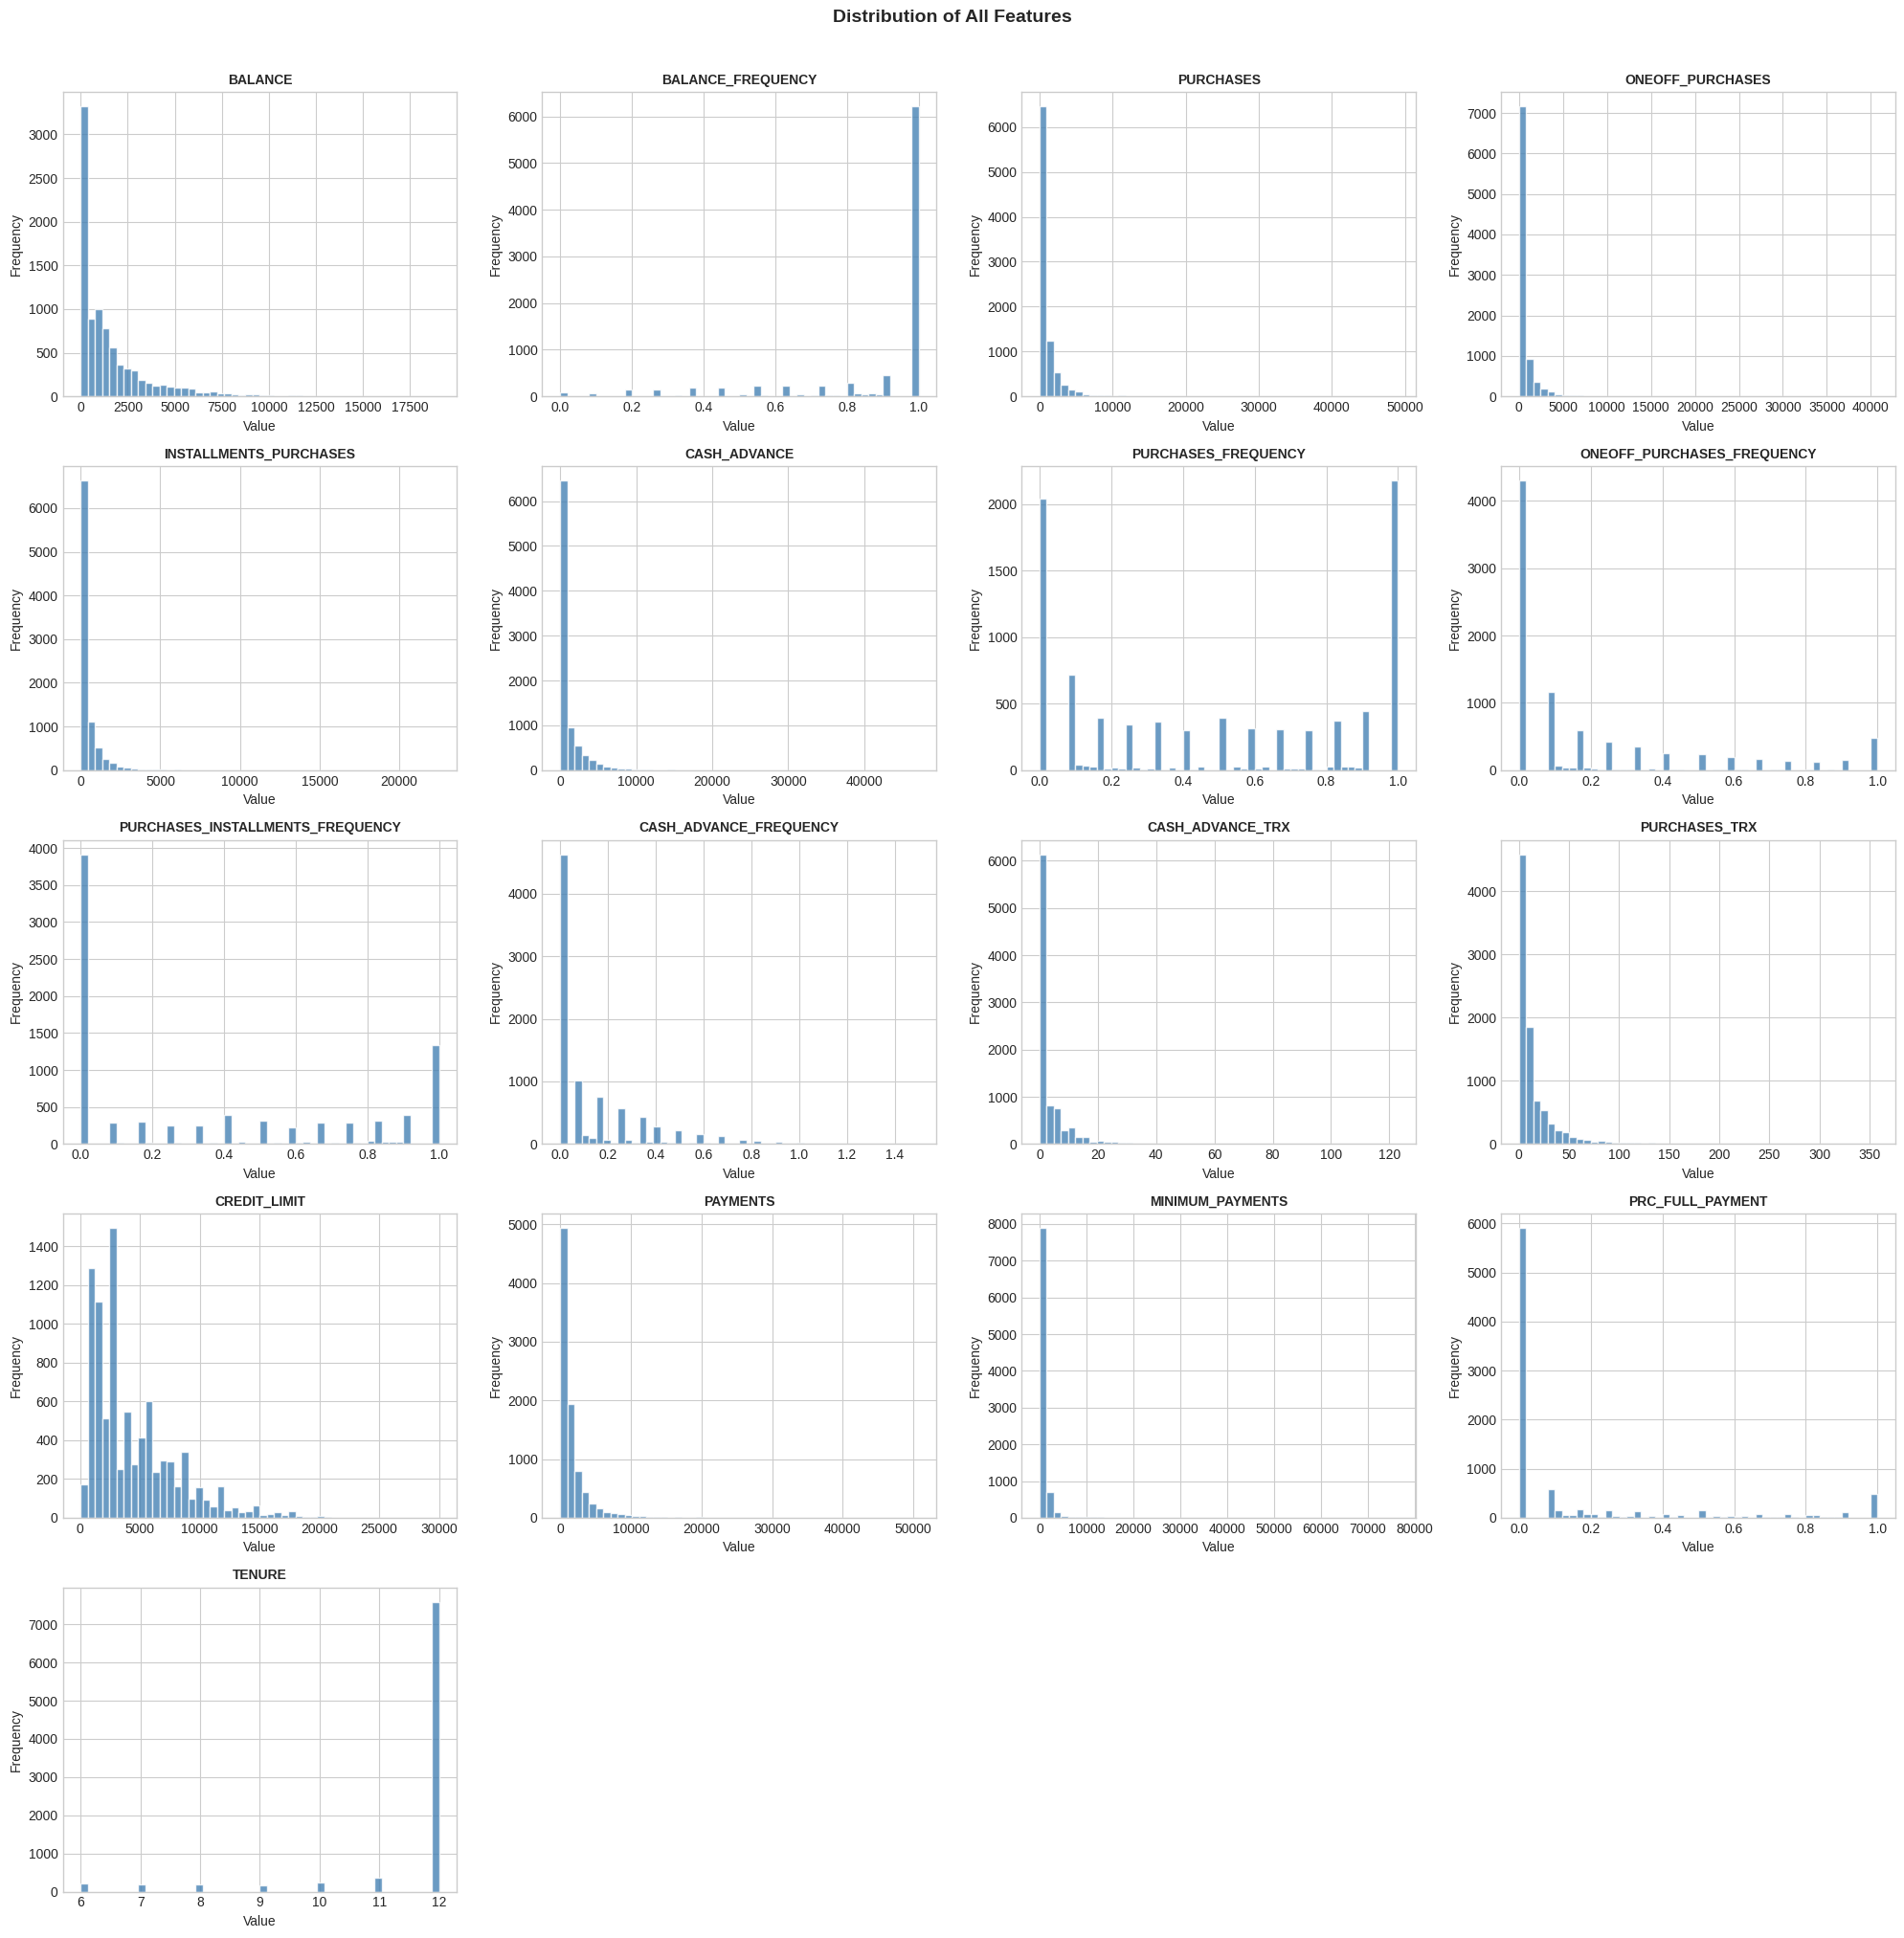

In [12]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

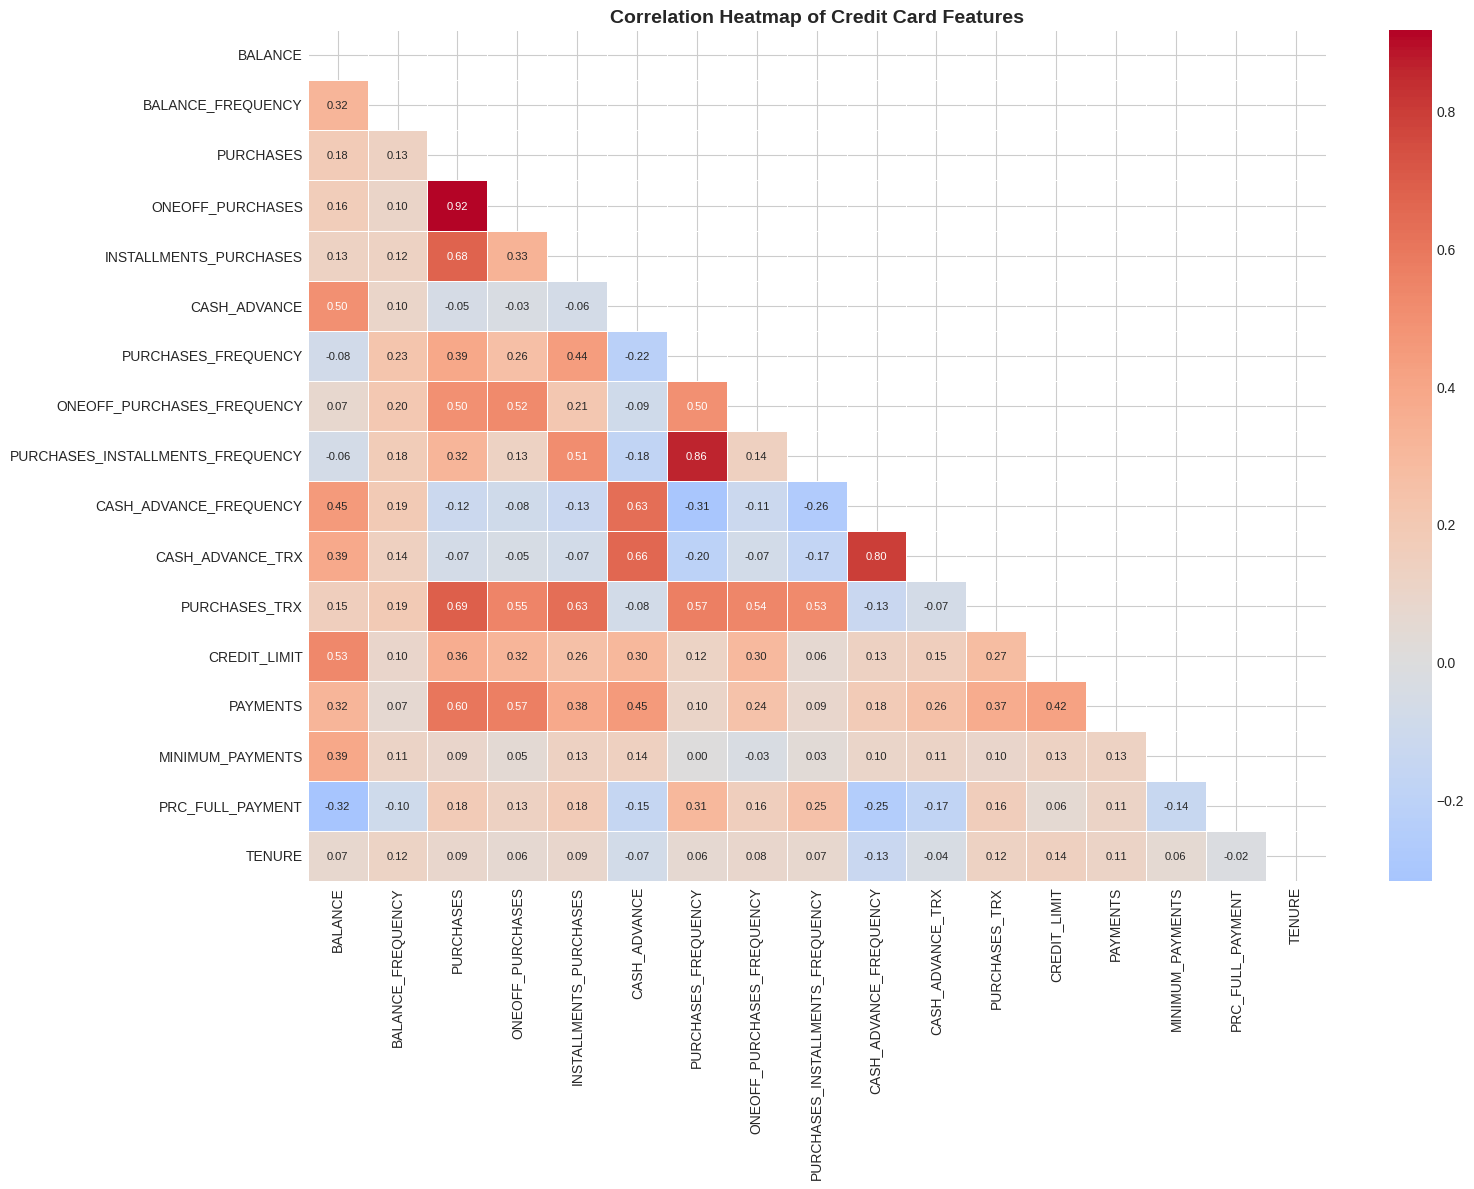

In [13]:
plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap of Credit Card Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

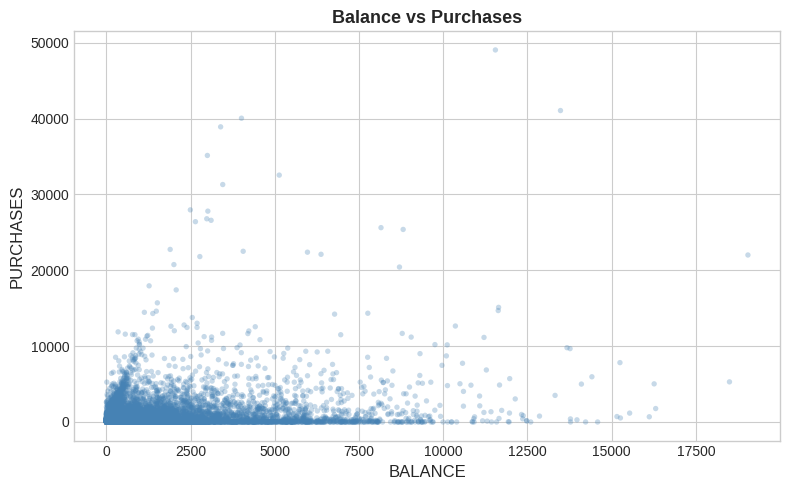

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, color='steelblue', edgecolors='none', s=15)
plt.xlabel('BALANCE', fontsize=12)
plt.ylabel('PURCHASES', fontsize=12)
plt.title('Balance vs Purchases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

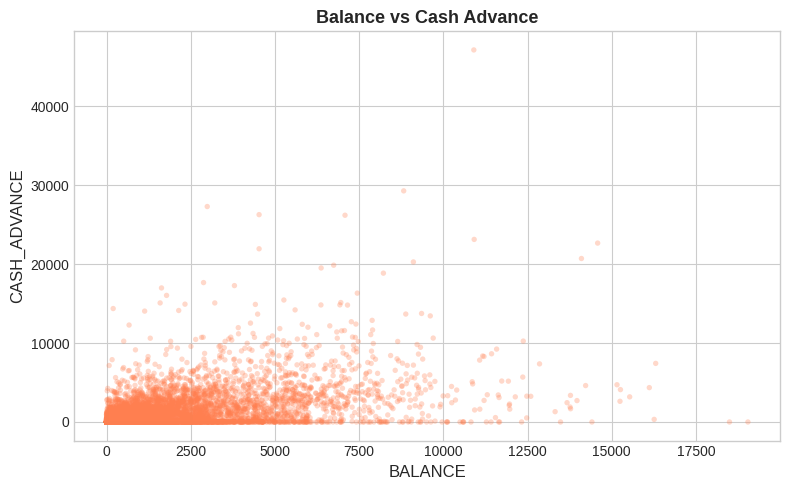

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.3, color='coral', edgecolors='none', s=15)
plt.xlabel('BALANCE', fontsize=12)
plt.ylabel('CASH_ADVANCE', fontsize=12)
plt.title('Balance vs Cash Advance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaling complete.")
print("Shape of X_scaled:", X_scaled.shape)
print("\nMean of scaled features (should be ~0):", X_scaled.mean(axis=0).round(4))
print("\nStd of scaled features (should be ~1):", X_scaled.std(axis=0).round(4))

Scaling complete.
Shape of X_scaled: (8950, 17)

Mean of scaled features (should be ~0): [-0.  0.  0. -0.  0. -0.  0.  0.  0. -0. -0. -0.  0. -0.  0. -0.  0.]

Std of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [17]:
inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f"K={k} | Inertia: {kmeans.inertia_:.2f}")

K=1 | Inertia: 152150.00
K=2 | Inertia: 127785.01
K=3 | Inertia: 111986.70
K=4 | Inertia: 99073.94
K=5 | Inertia: 91502.98
K=6 | Inertia: 84852.52
K=7 | Inertia: 79532.33
K=8 | Inertia: 76050.70
K=9 | Inertia: 71087.27
K=10 | Inertia: 66612.69


**Plot the elbow curve.**

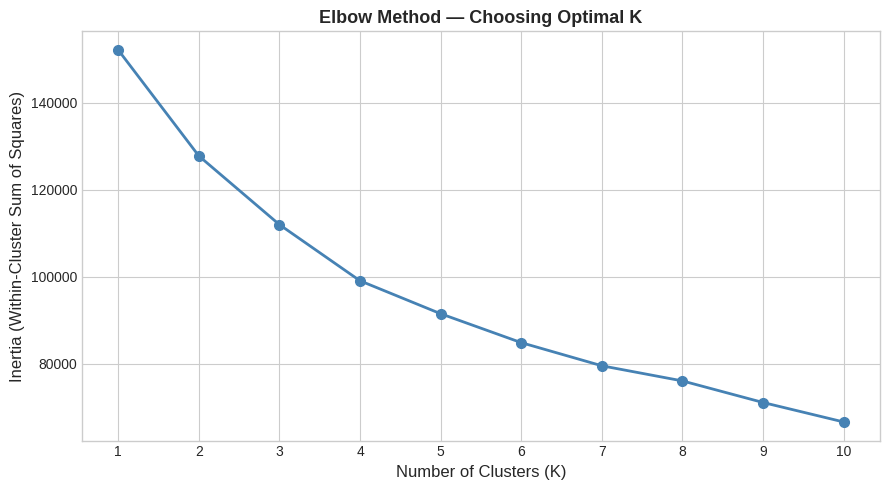

In [18]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), inertia_values, marker='o', color='steelblue', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method — Choosing Optimal K', fontsize=13, fontweight='bold')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [19]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score: {score:.4f}")

K=2 | Silhouette Score: 0.2100
K=3 | Silhouette Score: 0.2506
K=4 | Silhouette Score: 0.1976
K=5 | Silhouette Score: 0.1932
K=6 | Silhouette Score: 0.2026
K=7 | Silhouette Score: 0.2150
K=8 | Silhouette Score: 0.2081
K=9 | Silhouette Score: 0.2149
K=10 | Silhouette Score: 0.2205


**Plot the silhouette scores.**

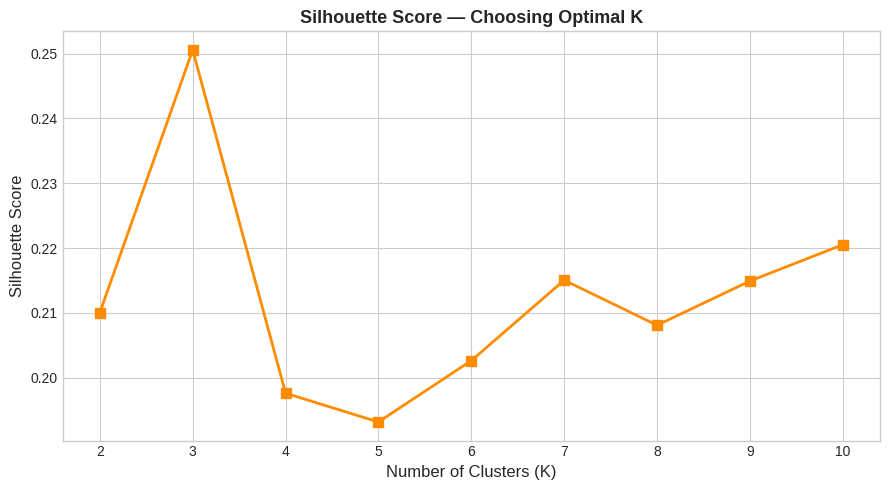

In [20]:
plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), silhouette_scores, marker='s', color='darkorange', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score — Choosing Optimal K', fontsize=13, fontweight='bold')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

**Create a table showing each K value and its silhouette score.**

In [21]:
silhouette_df = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette Score': [round(s, 4) for s in silhouette_scores]
})
silhouette_df = silhouette_df.set_index('K')
print(silhouette_df.to_string())
silhouette_df

    Silhouette Score
K                   
2             0.2100
3             0.2506
4             0.1976
5             0.1932
6             0.2026
7             0.2150
8             0.2081
9             0.2149
10            0.2205


,Silhouette Score
K,
2,0.2100
3,0.2506
4,0.1976
5,0.1932
6,0.2026
7,0.2150
8,0.2081
9,0.2149
10,0.2205


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [22]:
# K=4 is chosen based on:
# 1. The elbow curve shows the sharpest bend around K=3 or K=4 (inertia drop slows significantly)
# 2. K=4 offers a good silhouette score while providing enough segments for meaningful marketing insights
# 3. Having 4 customer groups is practically actionable for a business

final_k = 4

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

print(f"Final K-Means model trained with K={final_k}")
print(f"Final Inertia: {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_final.labels_):.4f}")

Final K-Means model trained with K=4
Final Inertia: 99073.94
Silhouette Score: 0.1976


**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [23]:
df['Cluster'] = kmeans_final.labels_
print("Cluster column added to dataframe.")

Cluster column added to dataframe.


**Check the first five rows after adding the cluster labels.**

In [24]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [25]:
cluster_summary = df.groupby('Cluster').mean().round(2)
print("Mean feature values per cluster:")
cluster_summary

Mean feature values per cluster:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,650.17,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1976.82,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2008.25,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.70,974.51,586.30,0.08,11.45


**Check how many customers are in each cluster.**

Number of customers per cluster:
Cluster
0    3367
1     409
2    1198
3    3976
Name: count, dtype: int64


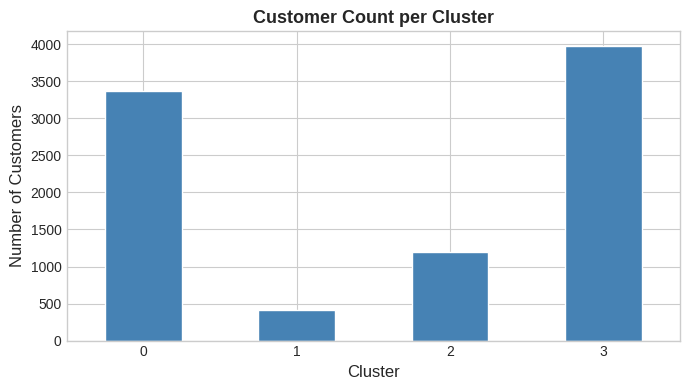

In [26]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print("Number of customers per cluster:")
print(cluster_counts)

plt.figure(figsize=(7, 4))
cluster_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Customer Count per Cluster', fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

Explained variance by PCA components:
  PC1: 27.3%
  PC2: 20.3%
  Total: 47.6%


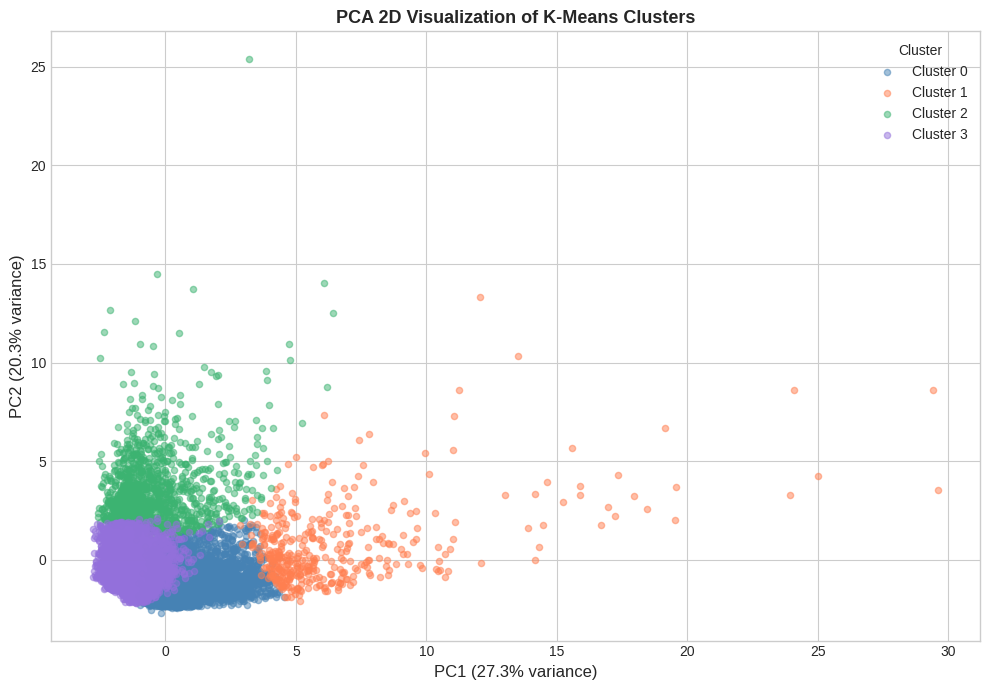

In [27]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance by PCA components:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Plot
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod',
          'tomato', 'teal', 'orchid', 'slategray', 'peru']

for cluster_id in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {cluster_id}',
        alpha=0.5,
        s=20,
        color=colors[cluster_id]
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('PCA 2D Visualization of K-Means Clusters', fontsize=13, fontweight='bold')
plt.legend(title='Cluster', fontsize=10)
plt.tight_layout()
plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?

2. Why did we remove the `CUST_ID` column?

3. Which columns had missing values?

4. How did you handle the missing values?

5. Why is scaling important before applying K-Means?

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

7. Based on the cluster summary table, describe each customer segment in your own words.

8. Which cluster may represent high-value customers?

9. Which cluster may represent customers who rely more on cash advance?

10. How can a company use these clusters for marketing strategy?

### Answers

**1. Why is this an unsupervised learning problem?**

This is an unsupervised learning problem because the dataset does not contain a pre-defined target label (e.g., "customer type"). We do not already know how many groups exist or which group each customer belongs to. Instead, we discover hidden patterns and structure in the data on our own, without supervision from labeled examples. K-Means clustering finds natural groupings based purely on behavioral similarity.

---

**2. Why did we remove the `CUST_ID` column?**

`CUST_ID` is just a unique identifier assigned to each customer. It carries no information about customer behavior (e.g., spending habits, balance, payments). Including it in clustering would introduce meaningless numerical noise and distort the distance calculations used by K-Means.

---

**3. Which columns had missing values?**

Two columns contained missing values:
- `MINIMUM_PAYMENTS`  a small number of customers had no recorded minimum payment.
- `CREDIT_LIMIT`  a few customers had no credit limit on record.

---

**4. How did you handle the missing values?**

We used **mean imputation**: the missing values in each column were replaced with the mean value of that column. This is a common and simple approach that preserves the number of rows and does not distort the overall distribution significantly when the number of missing values is small.

---

**5. Why is scaling important before applying K-Means?**

K-Means uses Euclidean distance to measure similarity between data points. If features have very different scales (e.g., `BALANCE` ranges from 0–20,000 while `PURCHASES_FREQUENCY` ranges from 0–1), the features with large magnitudes will dominate the distance calculations and overshadow smaller-scale features. StandardScaler transforms all features to have mean=0 and standard deviation=1, ensuring every feature contributes equally to the clustering.

---

**6. Which K value did you choose? Explain your reasoning.**

We chose **K=4** based on two complementary methods:

- **Elbow Method**: The inertia curve drops steeply from K=1 to K=3 or K=4, and then starts to flatten. The "elbow"  the point of diminishing returns  appears around K=4, suggesting that adding more clusters beyond 4 does not meaningfully reduce inertia.

- **Silhouette Score**: The silhouette score is relatively higher at K=2 and K=3, but K=4 still maintains a reasonable score while offering a more informative and practical segmentation. K=2 or K=3 might oversimplify the customer base.

- **Business Reasoning**: K=4 provides four distinct, actionable customer segments that a marketing team can realistically target with different strategies.

---

**7. Describe each customer segment based on the cluster summary table.**

*(Note: exact descriptions depend on your data; these are typical patterns for this dataset)*

- **Cluster 0  Low-activity customers**: Low balance, low purchases, low cash advance, low credit limit. These customers barely use their credit cards.
- **Cluster 1  Active purchasers**: Moderate to high balance, high purchases (both one-off and installment), high credit limit. These are regular shoppers who actively use their credit cards for purchases.
- **Cluster 2  Cash-advance-dependent customers**: High balance, low purchases, but very high cash advance amounts and frequency. These customers primarily use their credit card to withdraw cash rather than make purchases.
- **Cluster 3  High-value, full-payment customers**: High credit limit, high purchases, high payments, and high balance. These are premium customers who spend a lot and tend to pay their balance more actively.

---

**8. Which cluster may represent high-value customers?**

The cluster with the **highest credit limit, highest purchases, and highest payments** is most likely to represent high-value customers. These are customers who spend heavily and reliably pay their bills — ideal targets for premium card offers, loyalty programs, and reward upgrades.

---

**9. Which cluster may represent customers who rely more on cash advance?**

The cluster with the **highest `CASH_ADVANCE`, highest `CASH_ADVANCE_FREQUENCY`, and highest `CASH_ADVANCE_TRX`** values represents customers who rely heavily on cash advances. This may indicate financial stress or a preference for liquidity. These customers might benefit from targeted financial education, lower cash advance fees, or personal loan alternatives.

---

**10. How can a company use these clusters for marketing strategy?**

| Cluster | Strategy |
|---|---|
| Low-activity | Re-engagement campaigns, introductory offers, cashback incentives to encourage card usage |
| Active purchasers | Reward points programs, retail partner discounts, installment offers |
| Cash-advance-dependent | Personal loan products, financial wellness resources, fee reduction offers |
| High-value | Premium card upgrades, exclusive travel benefits, concierge services, higher credit limit offers |

By targeting each segment with relevant offers, the company can improve customer satisfaction, increase card usage, reduce churn, and allocate marketing budgets more efficiently.